# 09_dani_ensemble
## Ensemble — Weighted Average of the 12 Hybrid Models

Skema resmi mendaftarkan model Ensemble persis sama dengan Hybrid (`MSTL+UniLSTM, MSTL+BiLSTM,
MSTL+MultivariateLSTM, Prophet+UniLSTM, Prophet+BiLSTM, Prophet+MultiLSTM`), tapi deskripsi input-nya
cuma `"(gunakan hasil tuning dari deep learning)"` — **tanpa** embel-embel "Residual model Utama"
seperti Hybrid. Interpretasi yang dipakai di sini: **Ensemble menggabungkan prediksi dari 12 model
Hybrid yang sudah dilatih** (bukan membangun arsitektur baru), lewat weighted averaging.

### Strategi ensembling

- **Bobot** dihitung dari **validation RMSE** tiap model (10% ekor kronologis dari train — replikasi
  persis `validation_split=0.1, shuffle=False` yang dipakai saat training aslinya), **BUKAN** dari
  performa di test set — supaya bobot ensemble tidak ikut "mengintip" data test (itu akan jadi bentuk
  leakage tersendiri kalau bobotnya dipilih berdasar seberapa bagus performa di test).
- Model dengan validation RMSE lebih kecil dapat bobot lebih besar (`weight ∝ 1/RMSE`, dinormalisasi).
- **Simple average** (bobot sama rata) turut dihitung sebagai pembanding — supaya bisa dilihat apakah
  weighting benar-benar membantu dibanding sekadar rata-rata polos.
- Per-decomposition sub-ensemble (MSTL-only, Prophet-only) turut dihitung sebagai ablasi tambahan.

### Sumber model — TIDAK wajib menunggu notebook 08

`SOURCE` di bawah bisa diarahkan ke:
- `"nb07"` — model default hyperparameter (sudah tersedia sekarang, bisa langsung jalan paralel
  sementara notebook 08 masih tuning).
- `"nb08"` — model hasil tuning per-slot (dipakai begitu notebook 08 selesai; `look_back` per model
  dibaca otomatis dari `08_dani_hybrid_tuned_best_params.csv`, karena tiap slot punya `look_back`
  hasil tuning yang bisa berbeda-beda).

Tidak ada retraining di notebook ini — semua model di-load dari file `.keras` yang sudah tersimpan,
lalu dipakai untuk inference saja (murah secara compute, jauh lebih cepat dari 07/08).

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

project_root = next(
    (parent for parent in [Path.cwd(), *Path.cwd().parents] if (parent / "src").exists()),
    Path.cwd()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_loader import TimeSeriesDataLoader

import tensorflow as tf
from prophet import Prophet

print("Project root:", project_root)
print("TensorFlow:", tf.__version__)

Project root: /Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app
TensorFlow: 2.21.0


In [2]:
feature_path = (
    project_root / "data" / "processed" / "normalized" / "dataset_feature_engineered.csv"
)

df = pd.read_csv(feature_path)
df["datetime"] = pd.to_datetime(df["datetime"], utc=True)
df = df.set_index("datetime").sort_index()

CI_COL = "carbon_intensity"
RE_COL = "renewable_percentage"

df_core = df.dropna(subset=[CI_COL, RE_COL]).copy()

TRAIN_RATIO = 0.8
train_size = int(len(df_core) * TRAIN_RATIO)
train_raw = df_core.iloc[:train_size].copy()
test_raw = df_core.iloc[train_size:].copy()
TRAIN_END_INDEX = train_raw.index[-1]

print("Train:", train_raw.shape, "| Test:", test_raw.shape)

Train: (13996, 84) | Test: (3500, 84)


In [3]:
TEMPORAL_CYCLICAL = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"]

loader_time = TimeSeriesDataLoader()
all_index_df = pd.DataFrame(index=df_core.index)
cyclical_full = loader_time.add_time_features(all_index_df)[TEMPORAL_CYCLICAL].copy()

print("Cyclical features ready.")

Cyclical features ready.


## 1. Decomposition — recomputed fresh (needed for reconstruction, identical to nb07/nb08)

In [4]:
def compute_causal_decomposition(series, train_end_index, trend_window=168):
    trend = series.rolling(window=trend_window, min_periods=1).mean()
    deseasonalized = series - trend

    train_deseasonalized = deseasonalized.loc[:train_end_index]

    hour_profile = train_deseasonalized.groupby(train_deseasonalized.index.hour).mean()
    seasonal_24 = pd.Series(series.index.hour.map(hour_profile).astype(float), index=series.index)

    residual_after_24 = (
        train_deseasonalized.values
        - train_deseasonalized.index.hour.map(hour_profile).astype(float)
    )
    weekhour_key_train = train_deseasonalized.index.weekday * 24 + train_deseasonalized.index.hour
    weekhour_profile = pd.Series(residual_after_24, index=weekhour_key_train).groupby(level=0).mean()
    weekhour_key_full = series.index.weekday * 24 + series.index.hour
    seasonal_168 = pd.Series(weekhour_key_full.map(weekhour_profile).astype(float), index=series.index)

    resid = series - trend - seasonal_24 - seasonal_168

    return pd.DataFrame(
        {"trend": trend, "seasonal_24": seasonal_24, "seasonal_168": seasonal_168, "resid": resid},
        index=series.index
    )


mstl_ci = compute_causal_decomposition(df_core[CI_COL], TRAIN_END_INDEX, trend_window=168)
mstl_re = compute_causal_decomposition(df_core[RE_COL], TRAIN_END_INDEX, trend_window=168)

mstl_decomposition = {
    "CI_reconstruction": mstl_ci["trend"] + mstl_ci["seasonal_24"] + mstl_ci["seasonal_168"],
    "CI_resid": mstl_ci["resid"],
    "RE_reconstruction": mstl_re["trend"] + mstl_re["seasonal_24"] + mstl_re["seasonal_168"],
    "RE_resid": mstl_re["resid"],
}
print("MSTL decomposition ready.")

MSTL decomposition ready.


In [5]:
def run_prophet_decomposition(target_col):
    prophet_df = df_core.reset_index()[["datetime", target_col]].copy()
    prophet_df["datetime"] = prophet_df["datetime"].dt.tz_localize(None)
    prophet_df.columns = ["ds", "y"]

    train_prophet_df = prophet_df.iloc[:train_size]
    test_prophet_df = prophet_df.iloc[train_size:]

    model = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=True)
    model.fit(train_prophet_df)

    future = model.make_future_dataframe(periods=len(test_prophet_df), freq="h")
    forecast = model.predict(future)
    assert len(forecast) == len(df_core), "Prophet future length mismatch."

    reconstruction = pd.Series(forecast["yhat"].values, index=df_core.index)
    resid = df_core[target_col] - reconstruction
    return reconstruction, resid


print("Fitting Prophet on CI...")
ci_prophet_reconstruction, ci_prophet_resid = run_prophet_decomposition(CI_COL)
print("Fitting Prophet on RE...")
re_prophet_reconstruction, re_prophet_resid = run_prophet_decomposition(RE_COL)

prophet_decomposition = {
    "CI_reconstruction": ci_prophet_reconstruction,
    "CI_resid": ci_prophet_resid,
    "RE_reconstruction": re_prophet_reconstruction,
    "RE_resid": re_prophet_resid,
}

decompositions = {"mstl": mstl_decomposition, "prophet": prophet_decomposition}
print("Prophet decomposition ready.")

Fitting Prophet on CI...


12:50:50 - cmdstanpy - INFO - Chain [1] start processing
12:50:51 - cmdstanpy - INFO - Chain [1] done processing


Fitting Prophet on RE...


12:50:53 - cmdstanpy - INFO - Chain [1] start processing
12:50:54 - cmdstanpy - INFO - Chain [1] done processing


Prophet decomposition ready.


In [6]:
def build_residual_dataframe(decomp):
    df_resid = pd.DataFrame(index=df_core.index)
    df_resid["CI_resid"] = decomp["CI_resid"]
    df_resid["RE_resid"] = decomp["RE_resid"]
    df_resid[TEMPORAL_CYCLICAL] = cyclical_full[TEMPORAL_CYCLICAL]
    return df_resid


def get_feature_target_cols(target_group):
    if target_group == "CI":
        return ["CI_resid", *TEMPORAL_CYCLICAL], ["CI_resid"]
    elif target_group == "RE":
        return ["RE_resid", *TEMPORAL_CYCLICAL], ["RE_resid"]
    elif target_group == "MULTI":
        return ["CI_resid", "RE_resid", *TEMPORAL_CYCLICAL], ["CI_resid", "RE_resid"]
    raise ValueError("target_group must be CI, RE, or MULTI")


def evaluate(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]

    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    nonzero = y_true != 0
    mape = (
        np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100
        if np.any(nonzero) else np.nan
    )
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = np.nan if ss_tot == 0 else 1 - ss_res / ss_tot

    return {"MAE": mae, "RMSE": rmse, "MAPE (%)": mape, "R2": r2}


experiment_specs = [
    ("Uni-LSTM CI", "CI", "lstm"),
    ("Uni-LSTM RE", "RE", "lstm"),
    ("Multi-LSTM", "MULTI", "lstm"),
    ("BiLSTM CI", "CI", "bilstm"),
    ("BiLSTM RE", "RE", "bilstm"),
    ("BiLSTM Multi", "MULTI", "bilstm"),
]
decomposition_methods = ["mstl", "prophet"]

## 2. SOURCE toggle — pick which upstream notebook's saved models to ensemble

In [7]:
SOURCE = "nb07"  # ganti ke "nb08" begitu tuning selesai

TUNED_LOOK_BACK = 12  # dipakai seragam kalau SOURCE == "nb07"

def safe_name(model_name):
    return model_name.lower().replace(" ", "_").replace("-", "")

if SOURCE == "nb07":
    models_dir = project_root / "models" / "hybrid"
    def model_path(method, model_name):
        return models_dir / f"07_hybrid_{method}_{safe_name(model_name)}.keras"
    look_back_lookup = {
        (method, model_name): TUNED_LOOK_BACK
        for method in decomposition_methods
        for model_name, _, _ in experiment_specs
    }

elif SOURCE == "nb08":
    models_dir = project_root / "models" / "hybrid_tuned"
    def model_path(method, model_name):
        return models_dir / f"08_hybrid_tuned_{method}_{safe_name(model_name)}.keras"

    best_params_path = project_root / "results" / "hybrid_tuned" / "08_dani_hybrid_tuned_best_params.csv"
    best_params_df = pd.read_csv(best_params_path)
    look_back_lookup = {
        (row["Decomposition"], row["Model"]): int(row["look_back"])
        for _, row in best_params_df.iterrows()
    }

else:
    raise ValueError("SOURCE must be 'nb07' or 'nb08'")

print("SOURCE:", SOURCE)
print("Models dir:", models_dir)
print("Look-back per config:", look_back_lookup)

SOURCE: nb07
Models dir: /Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/models/hybrid
Look-back per config: {('mstl', 'Uni-LSTM CI'): 12, ('mstl', 'Uni-LSTM RE'): 12, ('mstl', 'Multi-LSTM'): 12, ('mstl', 'BiLSTM CI'): 12, ('mstl', 'BiLSTM RE'): 12, ('mstl', 'BiLSTM Multi'): 12, ('prophet', 'Uni-LSTM CI'): 12, ('prophet', 'Uni-LSTM RE'): 12, ('prophet', 'Multi-LSTM'): 12, ('prophet', 'BiLSTM CI'): 12, ('prophet', 'BiLSTM RE'): 12, ('prophet', 'BiLSTM Multi'): 12}


## 3. Load all 12 base models + compute validation RMSE (for ensemble weights)

In [8]:
VALIDATION_SPLIT = 0.1
FORECAST_HORIZON = 1

def get_validation_arrays(X, y, validation_split=VALIDATION_SPLIT):
    n_val = max(1, int(len(X) * validation_split))
    return X[-n_val:], y[-n_val:]


base_models = {}

for method in decomposition_methods:
    decomp = decompositions[method]
    df_resid = build_residual_dataframe(decomp)

    for model_name, target_group, architecture in experiment_specs:
        look_back = look_back_lookup[(method, model_name)]
        feature_cols, target_cols = get_feature_target_cols(target_group)

        path = model_path(method, model_name)
        if not path.exists():
            print(f"WARNING: missing model file, skipped: {path}")
            continue

        model = tf.keras.models.load_model(path)

        loader = TimeSeriesDataLoader()
        train_scaled, test_scaled = loader.split_and_scale(
            df=df_resid, feature_cols=feature_cols, target_cols=target_cols, train_ratio=TRAIN_RATIO
        )
        X_train, y_train = loader.create_sliding_window(
            train_scaled, target_cols=target_cols, look_back=look_back, forecast_horizon=FORECAST_HORIZON
        )
        X_test, y_test = loader.create_sliding_window(
            test_scaled, target_cols=target_cols, look_back=look_back, forecast_horizon=FORECAST_HORIZON
        )
        X_val, y_val = get_validation_arrays(X_train, y_train)

        # --- validation RMSE per target this model contributes to (raw scale) ---
        val_pred_scaled = model.predict(X_val, verbose=0)
        if len(target_cols) == 1:
            val_pred_scaled = val_pred_scaled.reshape(-1)

        val_pred_inv = loader.inverse_transform_predictions(val_pred_scaled, target_cols, feature_cols)
        val_actual_inv = loader.inverse_transform_predictions(y_val, target_cols, feature_cols)

        train_window_index = train_scaled.index[look_back:]
        val_index = train_window_index[-len(y_val):]

        val_rmse = {}
        for i, col in enumerate(target_cols):
            target_name = "CI" if col.startswith("CI") else "RE"
            recon = decomp[f"{target_name}_reconstruction"].loc[val_index].values
            if len(target_cols) == 1:
                pred_final = val_pred_inv.reshape(-1) + recon
            else:
                pred_final = val_pred_inv[:, i] + recon
            actual_raw = df_core.loc[val_index, CI_COL if target_name == "CI" else RE_COL].values
            val_rmse[target_name] = np.sqrt(np.mean((actual_raw - pred_final) ** 2))

        # --- one-step test predictions (raw scale), aligned to this model's own valid window ---
        test_pred_scaled = model.predict(X_test, verbose=0)
        if len(target_cols) == 1:
            test_pred_scaled = test_pred_scaled.reshape(-1)

        test_pred_inv = loader.inverse_transform_predictions(test_pred_scaled, target_cols, feature_cols)
        own_test_index = test_raw.index[look_back:]

        preds_by_target = {}
        for i, col in enumerate(target_cols):
            target_name = "CI" if col.startswith("CI") else "RE"
            recon = decomp[f"{target_name}_reconstruction"].loc[own_test_index].values
            if len(target_cols) == 1:
                final_pred = test_pred_inv.reshape(-1) + recon
            else:
                final_pred = test_pred_inv[:, i] + recon
            preds_by_target[target_name] = pd.Series(final_pred, index=own_test_index)

        base_models[(method, model_name)] = {
            "model": model,
            "feature_cols": feature_cols,
            "target_cols": target_cols,
            "target_group": target_group,
            "look_back": look_back,
            "val_rmse": val_rmse,
            "test_pred": preds_by_target,
        }

        print(f"Loaded: {model_name} | {method} | look_back={look_back} | val_rmse={val_rmse}")

print("\nTotal base models loaded:", len(base_models))

Split: Train=13996, Test=3500
Features scaled: 7
  Sliding window: X=(13984, 12, 7), y=(13984,)
  Sliding window: X=(3488, 12, 7), y=(3488,)
Loaded: Uni-LSTM CI | mstl | look_back=12 | val_rmse={'CI': np.float64(1.9678792802607674)}
Split: Train=13996, Test=3500
Features scaled: 7
  Sliding window: X=(13984, 12, 7), y=(13984,)
  Sliding window: X=(3488, 12, 7), y=(3488,)
Loaded: Uni-LSTM RE | mstl | look_back=12 | val_rmse={'RE': np.float64(0.2286527388353609)}
Split: Train=13996, Test=3500
Features scaled: 8
  Sliding window: X=(13984, 12, 8), y=(13984, 2)
  Sliding window: X=(3488, 12, 8), y=(3488, 2)
Loaded: Multi-LSTM | mstl | look_back=12 | val_rmse={'CI': np.float64(2.004155087504592), 'RE': np.float64(0.22881586394401401)}
Split: Train=13996, Test=3500
Features scaled: 7
  Sliding window: X=(13984, 12, 7), y=(13984,)
  Sliding window: X=(3488, 12, 7), y=(3488,)
Loaded: BiLSTM CI | mstl | look_back=12 | val_rmse={'CI': np.float64(1.9846858818022708)}
Split: Train=13996, Test=3500

## 4. One-step ensemble — simple average & inverse-RMSE weighted average

Semua model diselaraskan ke jendela test yang sama (`MAX_LOOK_BACK` = look-back terpanjang di antara
semua model, supaya SEMUA model punya prediksi valid di setiap titik jendela ini).

### Kenapa ada filter `multi_only`

Ensemble `all` (8 model per target untuk CI) mencampur model **univariate** (`Uni-LSTM CI`, `BiLSTM CI`
— tidak pernah melihat RE sama sekali) dengan model **multivariate** (`Multi-LSTM`, `BiLSTM Multi` — RE
ikut jadi input). Karena judul penelitian eksplisit "**Berbasis** Renewable dan Carbon Free Energy",
model CI yang univariate melemahkan premis itu kalau ikut disertakan begitu saja.

`multi_only` (dan turunannya `mstl_multi_only` / `prophet_multi_only`) membatasi ensemble CI hanya ke
`Multi-LSTM` + `BiLSTM Multi` — model yang benar-benar memakai CI & RE bersama sebagai input. Ini yang
direkomendasikan sebagai angka final yang dilaporkan; `all` / `mstl_only` / `prophet_only` tetap dihitung
sebagai pembanding/ablasi.

In [9]:
MAX_LOOK_BACK = max(bundle["look_back"] for bundle in base_models.values())
common_test_index = test_raw.index[MAX_LOOK_BACK:]

print("MAX_LOOK_BACK:", MAX_LOOK_BACK)
print("Common test window:", len(common_test_index), "rows")


def gather_target_predictions(target_name, method_filter=None, multi_only=False):
    rows = []
    for (method, model_name), bundle in base_models.items():
        if method_filter is not None and method != method_filter:
            continue
        if multi_only and bundle["target_group"] != "MULTI":
            continue
        if target_name not in bundle["test_pred"]:
            continue
        pred = bundle["test_pred"][target_name].reindex(common_test_index)
        rows.append({
            "key": f"{method}_{model_name}",
            "pred": pred,
            "weight_raw": 1.0 / bundle["val_rmse"][target_name]
        })
    return rows


def combine_predictions(rows, weighted):
    if weighted:
        total_w = sum(r["weight_raw"] for r in rows)
        weights = [r["weight_raw"] / total_w for r in rows]
    else:
        weights = [1.0 / len(rows)] * len(rows)

    combined = sum(w * r["pred"] for w, r in zip(weights, rows))
    return combined, {r["key"]: w for w, r in zip(weights, rows)}


# (label, method_filter, multi_only) - "multi_only" pakai HANYA Multi-LSTM & BiLSTM Multi,
# yang secara eksplisit memakai CI+RE bersama sebagai input.
ENSEMBLE_CONFIGS = [
    ("all", None, False),
    ("mstl_only", "mstl", False),
    ("prophet_only", "prophet", False),
    ("multi_only", None, True),
    ("mstl_multi_only", "mstl", True),
    ("prophet_multi_only", "prophet", True),
]

ensemble_results = []
ensemble_predictions = {}

for target_name in ["CI", "RE"]:
    actual = df_core.loc[common_test_index, CI_COL if target_name == "CI" else RE_COL].values

    for label, method_filter, multi_only in ENSEMBLE_CONFIGS:
        rows = gather_target_predictions(target_name, method_filter=method_filter, multi_only=multi_only)
        if len(rows) == 0:
            continue

        for weighted, tag in [(False, "Ensemble-Simple"), (True, "Ensemble-Weighted")]:
            combined, weights = combine_predictions(rows, weighted=weighted)
            metrics = evaluate(actual, combined.values)
            ensemble_results.append({
                "Ensemble": f"{tag} ({label})",
                "Target": target_name,
                "N_models": len(rows),
                **metrics
            })
            # Simpan versi rekomendasi (multi_only) untuk dipakai di plot & save nanti.
            if label == "multi_only":
                ensemble_predictions[(tag, target_name)] = combined

ensemble_results_df = pd.DataFrame(ensemble_results)
print("=== ONE-STEP ENSEMBLE EVALUATION ===")
display(ensemble_results_df.sort_values(["Target", "RMSE"]).reset_index(drop=True))

print("\n=== all vs multi_only, per target (RMSE) ===")
for target_name in ["CI", "RE"]:
    sub = ensemble_results_df[ensemble_results_df["Target"] == target_name]
    all_rmse = sub[sub["Ensemble"].str.contains(r"\(all\)")]["RMSE"].min()
    multi_rmse = sub[sub["Ensemble"].str.contains(r"\(multi_only\)")]["RMSE"].min()
    if pd.notna(all_rmse) and pd.notna(multi_rmse):
        diff_pct = (multi_rmse - all_rmse) / all_rmse * 100
        print(f"{target_name}: all={all_rmse:.4f} | multi_only={multi_rmse:.4f} | "
              f"multi_only {'lebih jelek' if diff_pct > 0 else 'lebih bagus/setara'} {abs(diff_pct):.2f}%")

MAX_LOOK_BACK: 12
Common test window: 3488 rows
=== ONE-STEP ENSEMBLE EVALUATION ===


,Ensemble,Target,N_models,MAE,RMSE,MAPE (%),R2
0,Ensemble-Weighted (mstl_only),CI,4,1.500034,2.012814,0.256629,0.950230
1,Ensemble-Simple (mstl_only),CI,4,1.500110,2.012887,0.256643,0.950227
2,Ensemble-Weighted (all),CI,8,1.530766,2.031717,0.262133,0.949291
3,Ensemble-Simple (all),CI,8,1.537114,2.038151,0.263228,0.948969
4,Ensemble-Weighted (mstl_multi_only),CI,2,1.533900,2.047249,0.262516,0.948513
5,Ensemble-Simple (mstl_multi_only),CI,2,1.534492,2.047905,0.262618,0.948480
6,Ensemble-Weighted (multi_only),CI,4,1.590240,2.099199,0.272389,0.945867
7,Ensemble-Simple (multi_only),CI,4,1.595678,2.105010,0.273325,0.945567
8,Ensemble-Weighted (prophet_only),CI,4,1.802389,2.326653,0.308740,0.933500
9,Ensemble-Simple (prophet_only),CI,4,1.802967,2.327131,0.308849,0.933473



=== all vs multi_only, per target (RMSE) ===
CI: all=2.0317 | multi_only=2.0992 | multi_only lebih jelek 3.32%
RE: all=0.2227 | multi_only=0.2284 | multi_only lebih jelek 2.58%


In [10]:
# Compare best ensemble vs best individual base model, per target.
individual_results = []
for (method, model_name), bundle in base_models.items():
    for target_name, pred in bundle["test_pred"].items():
        pred_aligned = pred.reindex(common_test_index)
        actual = df_core.loc[common_test_index, CI_COL if target_name == "CI" else RE_COL].values
        metrics = evaluate(actual, pred_aligned.values)
        individual_results.append({
            "Model": f"{method}_{model_name}", "Target": target_name, **metrics
        })

individual_results_df = pd.DataFrame(individual_results)

for target_name in ["CI", "RE"]:
    best_individual = individual_results_df[individual_results_df["Target"] == target_name].sort_values("RMSE").iloc[0]
    best_ensemble = ensemble_results_df[ensemble_results_df["Target"] == target_name].sort_values("RMSE").iloc[0]

    print(f"--- {target_name} ---")
    print(f"Best individual base model : {best_individual['Model']:30s} RMSE={best_individual['RMSE']:.4f}")
    print(f"Best ensemble               : {best_ensemble['Ensemble']:30s} RMSE={best_ensemble['RMSE']:.4f}")
    improvement = (best_individual["RMSE"] - best_ensemble["RMSE"]) / best_individual["RMSE"] * 100
    print(f"Improvement: {improvement:.2f}%\n")

--- CI ---
Best individual base model : mstl_BiLSTM CI                 RMSE=2.0276
Best ensemble               : Ensemble-Weighted (mstl_only)  RMSE=2.0128
Improvement: 0.73%

--- RE ---
Best individual base model : mstl_Uni-LSTM RE               RMSE=0.2199
Best ensemble               : Ensemble-Simple (mstl_only)    RMSE=0.2227
Improvement: -1.24%



## 5. Multistep ensemble — rolling-origin, shared origins across all base models

Origin dihitung sekali dari `MAX_LOOK_BACK` dan dipakai SAMA untuk semua model, supaya prediksi tiap
model bisa diselaraskan (per origin, per horizon-step) sebelum digabung.

In [11]:
MULTISTEP_HORIZON = 24
ORIGIN_STRIDE = 24
N_ORIGINS_MAX = 100


def rolling_origin_recursive_forecast(model, loader, test_scaled, feature_cols, target_cols, horizon, look_back, origins):
    data = test_scaled[feature_cols].values
    target_idx = [feature_cols.index(c) for c in target_cols]

    per_origin_preds = []
    for origin in origins:
        history_window = data[origin - look_back: origin].copy()
        preds_scaled = []

        for h in range(horizon):
            X_step = history_window[np.newaxis, :, :]
            pred_scaled = model.predict(X_step, verbose=0).reshape(-1)
            preds_scaled.append(pred_scaled)

            next_row = data[origin + h].copy()
            for i, idx in enumerate(target_idx):
                next_row[idx] = pred_scaled[i]
            history_window = np.vstack([history_window[1:], next_row])

        preds_scaled = np.array(preds_scaled)
        preds_inv = loader.inverse_transform_predictions(preds_scaled, target_cols=target_cols, feature_cols=feature_cols)
        per_origin_preds.append((origin, preds_inv))

    return per_origin_preds


# Shared origins - valid for every model regardless of its own (possibly smaller) look_back.
sample_test_scaled_len = len(test_raw)  # same length across all configs (same df_core/test split)
shared_origins = list(range(MAX_LOOK_BACK, sample_test_scaled_len - MULTISTEP_HORIZON, ORIGIN_STRIDE))[:N_ORIGINS_MAX]

print("Shared origins:", len(shared_origins))

Shared origins: 100


In [12]:
# Re-run rolling-origin recursive forecast per base model (cheap: inference only, no retraining).
base_multistep_preds = {}

for (method, model_name), bundle in base_models.items():
    decomp = decompositions[method]
    df_resid = build_residual_dataframe(decomp)
    feature_cols, target_cols = bundle["feature_cols"], bundle["target_cols"]

    loader = TimeSeriesDataLoader()
    _, test_scaled = loader.split_and_scale(df_resid, feature_cols, target_cols, train_ratio=TRAIN_RATIO)

    per_origin_preds = rolling_origin_recursive_forecast(
        bundle["model"], loader, test_scaled, feature_cols, target_cols,
        horizon=MULTISTEP_HORIZON, look_back=bundle["look_back"], origins=shared_origins
    )

    # store as {target_name: DataFrame[origin_idx, horizon_step] = raw-scale prediction}
    per_target_grid = {t: {} for t in ["CI", "RE"] if t in [("CI" if c.startswith("CI") else "RE") for c in target_cols]}

    for origin, preds_inv in per_origin_preds:
        preds_inv = np.atleast_2d(preds_inv)
        if preds_inv.shape[0] == 1 and len(target_cols) > 1:
            preds_inv = preds_inv.reshape(-1, len(target_cols))
        elif preds_inv.ndim == 1:
            preds_inv = preds_inv.reshape(-1, 1)

        origin_index = test_scaled.index[origin: origin + MULTISTEP_HORIZON]

        for i, col in enumerate(target_cols):
            target_name = "CI" if col.startswith("CI") else "RE"
            recon_vals = decomp[f"{target_name}_reconstruction"].loc[origin_index].values
            final_pred = preds_inv[:, i] + recon_vals
            per_target_grid[target_name][origin] = final_pred

    base_multistep_preds[(method, model_name)] = per_target_grid
    print(f"Multistep done: {model_name} | {method}")

Split: Train=13996, Test=3500
Features scaled: 7
Multistep done: Uni-LSTM CI | mstl
Split: Train=13996, Test=3500
Features scaled: 7
Multistep done: Uni-LSTM RE | mstl
Split: Train=13996, Test=3500
Features scaled: 8
Multistep done: Multi-LSTM | mstl
Split: Train=13996, Test=3500
Features scaled: 7
Multistep done: BiLSTM CI | mstl
Split: Train=13996, Test=3500
Features scaled: 7
Multistep done: BiLSTM RE | mstl
Split: Train=13996, Test=3500
Features scaled: 8
Multistep done: BiLSTM Multi | mstl
Split: Train=13996, Test=3500
Features scaled: 7
Multistep done: Uni-LSTM CI | prophet
Split: Train=13996, Test=3500
Features scaled: 7
Multistep done: Uni-LSTM RE | prophet
Split: Train=13996, Test=3500
Features scaled: 8
Multistep done: Multi-LSTM | prophet
Split: Train=13996, Test=3500
Features scaled: 7
Multistep done: BiLSTM CI | prophet
Split: Train=13996, Test=3500
Features scaled: 7
Multistep done: BiLSTM RE | prophet
Split: Train=13996, Test=3500
Features scaled: 8
Multistep done: BiLST

In [13]:
# Combine multistep predictions across contributing models (simple & weighted), per origin/horizon.
# Sama seperti one-step: "multi_only" membatasi ke Multi-LSTM + BiLSTM Multi saja (rekomendasi
# untuk dilaporkan pada CI), sisanya ("all", "mstl_only", "prophet_only") tetap dihitung sebagai
# pembanding/ablasi. Reuse ENSEMBLE_CONFIGS dari section one-step.
ensemble_horizon_results = []

for target_name in ["CI", "RE"]:
    for label, method_filter, multi_only in ENSEMBLE_CONFIGS:
        contributing = [
            (key, bundle) for key, bundle in base_models.items()
            if target_name in base_multistep_preds[key]
            and (method_filter is None or key[0] == method_filter)
            and (not multi_only or bundle["target_group"] == "MULTI")
        ]
        if len(contributing) == 0:
            continue

        for weighted, tag in [(False, "Ensemble-Simple"), (True, "Ensemble-Weighted")]:
            if weighted:
                total_w = sum(1.0 / b["val_rmse"][target_name] for _, b in contributing)
                weights = {key: (1.0 / b["val_rmse"][target_name]) / total_w for key, b in contributing}
            else:
                weights = {key: 1.0 / len(contributing) for key, b in contributing}

            for origin in shared_origins:
                combined = np.zeros(MULTISTEP_HORIZON)
                for key, _ in contributing:
                    combined += weights[key] * base_multistep_preds[key][target_name][origin]

                origin_index = test_raw.index[origin: origin + MULTISTEP_HORIZON]
                actual = df_core.loc[origin_index, CI_COL if target_name == "CI" else RE_COL].values

                for h in range(MULTISTEP_HORIZON):
                    ensemble_horizon_results.append({
                        "Ensemble": f"{tag} ({label})", "Target": target_name,
                        "Horizon": h + 1, "AbsError": abs(actual[h] - combined[h])
                    })

ensemble_horizon_df = pd.DataFrame(ensemble_horizon_results)
ensemble_horizon_summary = (
    ensemble_horizon_df
    .groupby(["Ensemble", "Target", "Horizon"], as_index=False)["AbsError"]
    .mean()
    .rename(columns={"AbsError": "MAE_at_horizon"})
)

print("=== MULTISTEP ENSEMBLE MAE BY HORIZON ===")
display(ensemble_horizon_summary.head(10))

=== MULTISTEP ENSEMBLE MAE BY HORIZON ===


,Ensemble,Target,Horizon,MAE_at_horizon
0,Ensemble-Simple (all),CI,1,1.209097
1,Ensemble-Simple (all),CI,2,3.034160
2,Ensemble-Simple (all),CI,3,3.347724
3,Ensemble-Simple (all),CI,4,3.447931
4,Ensemble-Simple (all),CI,5,3.730972
5,Ensemble-Simple (all),CI,6,4.464632
6,Ensemble-Simple (all),CI,7,4.167038
7,Ensemble-Simple (all),CI,8,4.883894
8,Ensemble-Simple (all),CI,9,5.285478
9,Ensemble-Simple (all),CI,10,5.411500


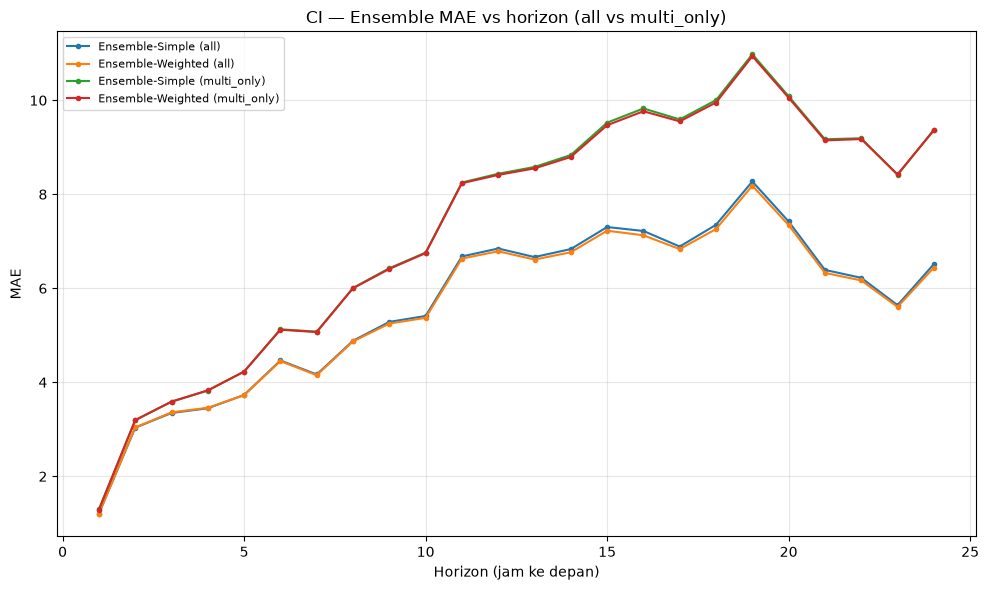

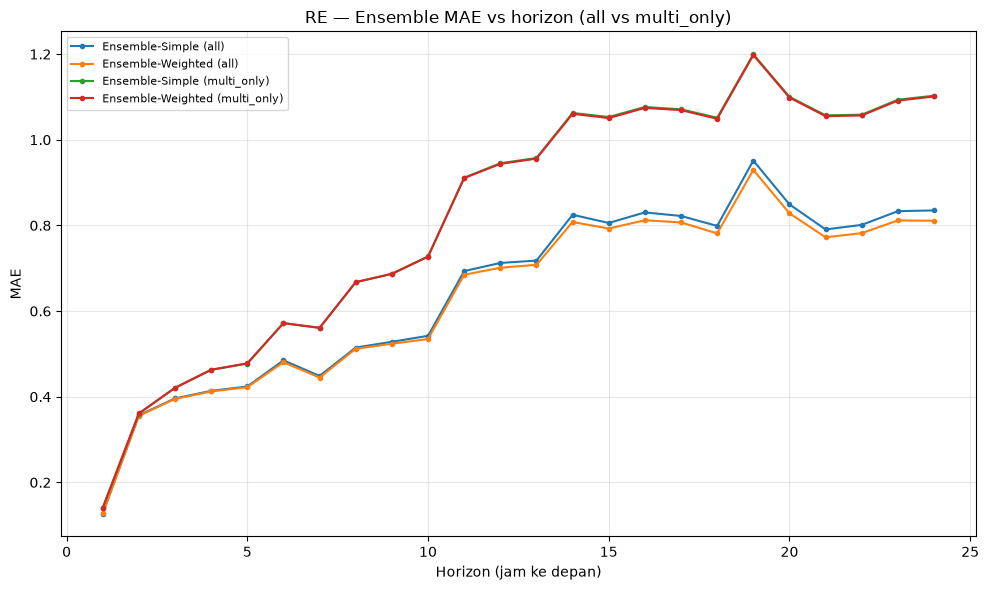

In [14]:
# Fokus perbandingan: "all" (8 model, termasuk univariate) vs "multi_only" (rekomendasi, CI+RE
# selalu dipakai bersama sebagai input) - untuk kedua strategi (Simple, Weighted).
compare_labels = [
    "Ensemble-Simple (all)", "Ensemble-Weighted (all)",
    "Ensemble-Simple (multi_only)", "Ensemble-Weighted (multi_only)",
]

for target_name in ["CI", "RE"]:
    fig, ax = plt.subplots(figsize=(10, 6))
    for label in compare_labels:
        subset = ensemble_horizon_summary[
            (ensemble_horizon_summary["Ensemble"] == label) & (ensemble_horizon_summary["Target"] == target_name)
        ].sort_values("Horizon")
        if len(subset) == 0:
            continue
        ax.plot(subset["Horizon"], subset["MAE_at_horizon"], label=label, marker="o", markersize=3)

    ax.set_xlabel("Horizon (jam ke depan)")
    ax.set_ylabel("MAE")
    ax.set_title(f"{target_name} — Ensemble MAE vs horizon (all vs multi_only)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

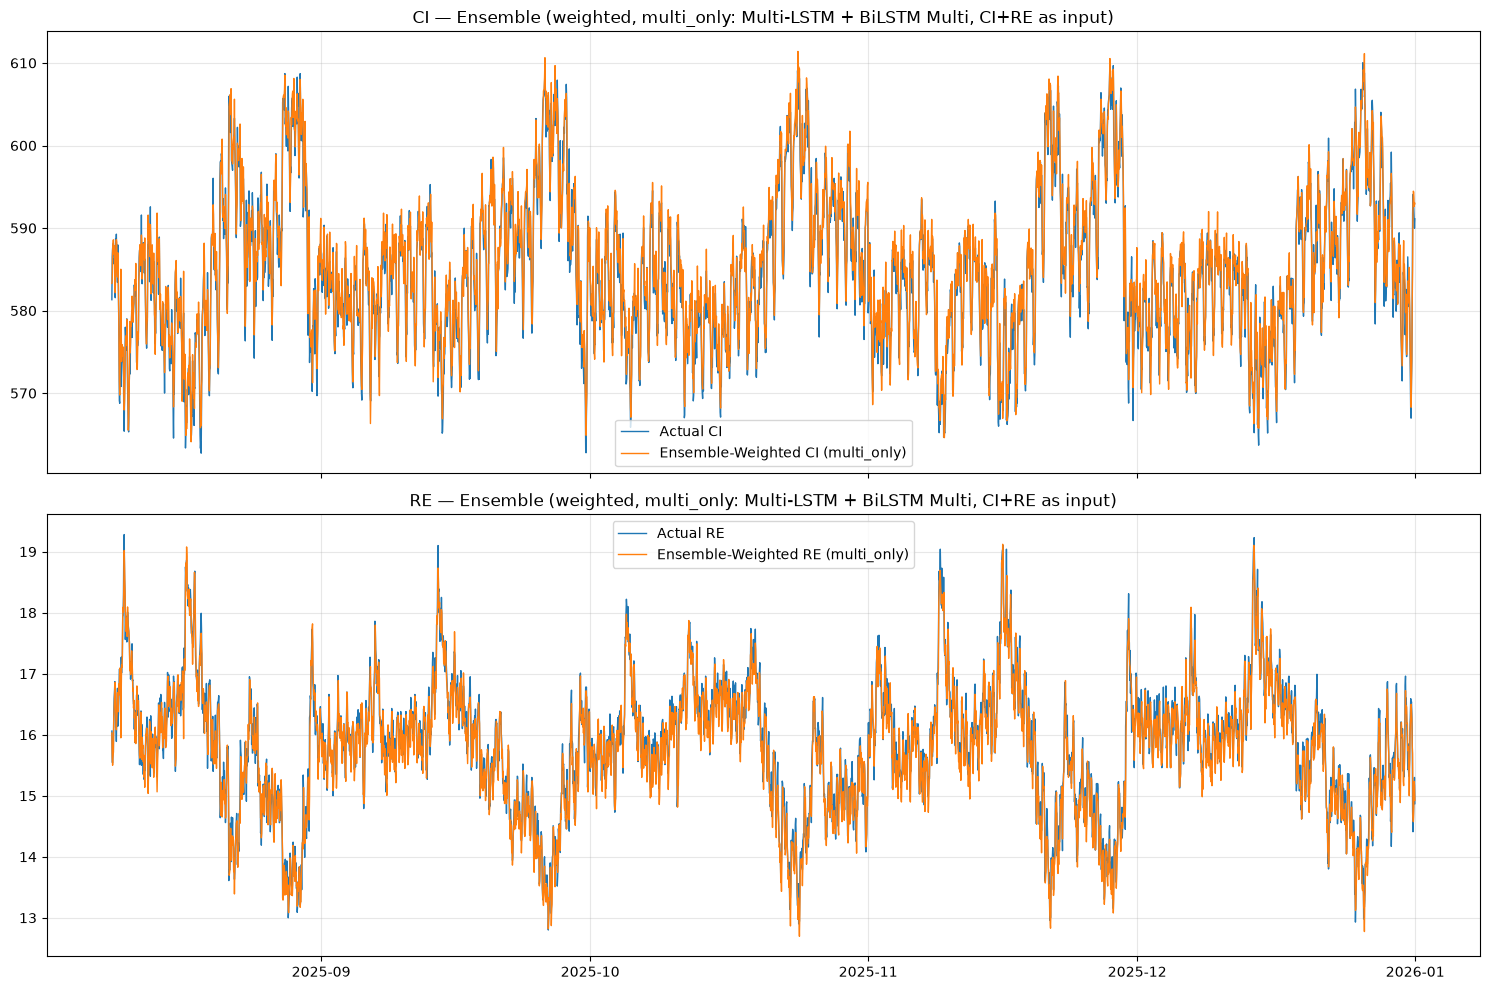

In [15]:
plot_index = common_test_index

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

axes[0].plot(plot_index, df_core.loc[plot_index, CI_COL].values, label="Actual CI", linewidth=1)
axes[0].plot(plot_index, ensemble_predictions[("Ensemble-Weighted", "CI")].values, label="Ensemble-Weighted CI (multi_only)", linewidth=1)
axes[0].set_title("CI — Ensemble (weighted, multi_only: Multi-LSTM + BiLSTM Multi, CI+RE as input)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(plot_index, df_core.loc[plot_index, RE_COL].values, label="Actual RE", linewidth=1)
axes[1].plot(plot_index, ensemble_predictions[("Ensemble-Weighted", "RE")].values, label="Ensemble-Weighted RE (multi_only)", linewidth=1)
axes[1].set_title("RE — Ensemble (weighted, multi_only: Multi-LSTM + BiLSTM Multi, CI+RE as input)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
results_dir = project_root / "results" / "ensemble"
results_dir.mkdir(parents=True, exist_ok=True)

ensemble_results_df.to_csv(results_dir / f"09_dani_ensemble_onestep_metrics_{SOURCE}.csv", index=False)
individual_results_df.to_csv(results_dir / f"09_dani_ensemble_individual_base_metrics_{SOURCE}.csv", index=False)
ensemble_horizon_summary.to_csv(results_dir / f"09_dani_ensemble_multistep_horizon_mae_{SOURCE}.csv", index=False)

print("Saved results to:", results_dir, f"(SOURCE={SOURCE})")

Saved results to: /Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/results/ensemble (SOURCE=nb07)


## Ringkasan

- **`ensemble_results_df`** — one-step: Simple vs Weighted average, dengan 6 varian gabungan model
  (`all`, `mstl_only`, `prophet_only`, `multi_only`, `mstl_multi_only`, `prophet_multi_only`).
- **`individual_results_df`** — performa tiap model individu di jendela test yang sama, buat baseline
  perbandingan langsung ke ensemble.
- **`ensemble_horizon_summary`** — kurva MAE-vs-horizon untuk semua varian & strategi ensembling.
- **Plot & `ensemble_predictions` final** memakai varian **`multi_only`** (Weighted) sebagai rekomendasi
  default untuk CI — supaya konsisten dengan premis "berbasis Renewable Energy" di judul penelitian
  (`Uni-LSTM CI` / `BiLSTM CI` yang univariate dikeluarkan dari kombinasi CI-nya).

Yang perlu diperiksa:
1. Cek print **"all vs multi_only, per target (RMSE)"** — kalau selisihnya kecil, `multi_only` aman
   dipakai sebagai angka resmi (lebih defensible ke premis judul). Kalau `multi_only` jelek jauh, itu
   trade-off yang perlu didiskusikan eksplisit di paper: defensibility metodologi vs performa mentah.
2. Apakah ensemble (mana pun variannya) benar-benar mengungguli model individu terbaik — cek print
   "Improvement (%)". Kalau minus/negatif, itu insight valid juga: model terbaik individu sudah cukup
   dominan, menggabungkan model lain malah menariknya turun.
3. Apakah weighted mengungguli simple average secara konsisten — kalau bedanya tipis, simple average
   lebih defensible untuk dilaporkan (lebih sederhana, tidak butuh penjelasan skema bobot).
4. Ganti `SOURCE = "nb08"` begitu tuning selesai, rerun, bandingkan apakah ensemble dari model yang
   sudah di-tuning memberi hasil yang jauh lebih baik dari ensemble model default (nb07).